# Evaluator-optimizer
In evaluator-optimizer workflows, one LLM call creates a response and the other evaluates that response. If the evaluator or a human-in-the-loop determines the response needs refinement, feedback is provided and the response is recreated. This loop continues until an acceptable response is generated.

Evaluator-optimizer workflows are commonly used when there’s particular success criteria for a task, but iteration is required to meet that criteria. For example, there’s not always a perfect match when translating text between two languages. It might take a few iterations to generate a translation with the same meaning across the two languages.

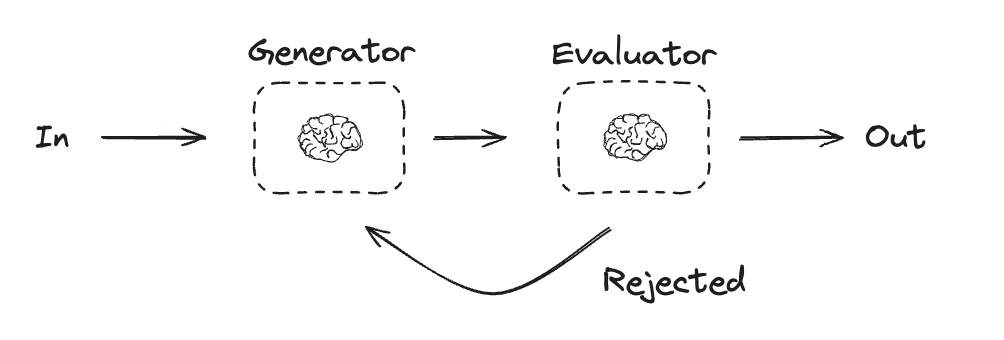

In [ ]:
import os
from dotenv import load_dotenv

load_dotenv()

os.environ["ANTHROPIC_API_KEY"] = os.getenv("ANTHROPIC_API_KEY")

from langchain.chat_models import init_chat_model

llm = init_chat_model("claude-haiku-4-5", temperature=0, max_tokens=100)

## By using the Graph API

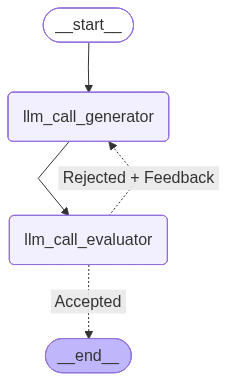

Here's a cat joke for you:

**Why don't cats play poker in the jungle?**

*Too many cheetahs!* 🐱

---

Or how about this one:

**What do you call a cat that gets everything it wants?**

*Purrr-suasive!* 😄


In [ ]:
from typing_extensions import Literal
from langchain.messages import HumanMessage, SystemMessage
from langgraph.graph import StateGraph, START, END
from pydantic import BaseModel, Field
from typing_extensions import TypedDict
from IPython.display import display, Image


# Graph state
class State(TypedDict):
    joke: str
    topic: str
    feedback: str
    funny_or_not: str


# Schema for structured output to use in evaluation
class Feedback(BaseModel):
    grade: Literal["funny", "not funny"] = Field(
        description="Decide if the joke is funny or not.",
    )
    feedback: str = Field(
        description="If the joke is not funny, provide feedback on how to improve it.",
    )


# Augment the LLM with schema for structured output
evaluator = llm.with_structured_output(Feedback)


# Nodes
def llm_call_generator(state: State):
    """LLM generates a joke"""

    if state.get("feedback"):
        msg = llm.invoke(
            f"Write a joke about {state['topic']} but take into account the feedback: {state['feedback']}"
        )
    else:
        msg = llm.invoke(f"Write a joke about {state['topic']}")
    return {"joke": msg.content}


def llm_call_evaluator(state: State):
    """LLM evaluates the joke"""

    grade = evaluator.invoke(f"Grade the joke {state['joke']}")
    return {"funny_or_not": grade.grade, "feedback": grade.feedback}


# Conditional edge function to route back to joke generator or end based upon feedback from the evaluator
def route_joke(state: State):
    """Route back to joke generator or end based upon feedback from the evaluator"""

    if state["funny_or_not"] == "funny":
        return "Accepted"
    elif state["funny_or_not"] == "not funny":
        return "Rejected + Feedback"


# Build workflow
optimizer_builder = StateGraph(State)

# Add the nodes
optimizer_builder.add_node("llm_call_generator", llm_call_generator)
optimizer_builder.add_node("llm_call_evaluator", llm_call_evaluator)

# Add edges to connect nodes
optimizer_builder.add_edge(START, "llm_call_generator")
optimizer_builder.add_edge("llm_call_generator", "llm_call_evaluator")
optimizer_builder.add_conditional_edges(
    "llm_call_evaluator",
    route_joke,
    {  # Name returned by route_joke : Name of next node to visit
        "Accepted": END,
        "Rejected + Feedback": "llm_call_generator",
    },
)

# Compile the workflow
optimizer_workflow = optimizer_builder.compile()

# Show the workflow
display(Image(optimizer_workflow.get_graph().draw_mermaid_png()))

# Invoke
state = optimizer_workflow.invoke({"topic": "Cats"})
print(state["joke"])

## By using the Functional API

In [ ]:
from pydantic import BaseModel, Field
from langgraph.func import entrypoint, task


# Schema for structured output to use in evaluation
class Feedback(BaseModel):
    grade: Literal["funny", "not funny"] = Field(
        description="Decide if the joke is funny or not.",
    )
    feedback: str = Field(
        description="If the joke is not funny, provide feedback on how to improve it.",
    )


# Augment the LLM with schema for structured output
evaluator = llm.with_structured_output(Feedback)


# Nodes
@task
def llm_call_generator(topic: str, feedback: Feedback):
    """LLM generates a joke"""
    if feedback:
        msg = llm.invoke(
            f"Write a joke about {topic} but take into account the feedback: {feedback}"
        )
    else:
        msg = llm.invoke(f"Write a joke about {topic}")
    return msg.content


@task
def llm_call_evaluator(joke: str):
    """LLM evaluates the joke"""
    feedback = evaluator.invoke(f"Grade the joke {joke}")
    return feedback


@entrypoint()
def optimizer_workflow(topic: str):
    feedback = None
    while True:
        joke = llm_call_generator(topic, feedback).result()
        feedback = llm_call_evaluator(joke).result()
        if feedback.grade == "funny":
            break

    return joke


# Invoke
for step in optimizer_workflow.stream("Cats", stream_mode="updates"):
    print(step)
    print("\n")

{'llm_call_generator': "Here's a cat joke for you:\n\n**Why don't cats play poker in the jungle?**\n\n*Too many cheetahs!* 🐱\n\n---\n\nOr how about this one:\n\n**What do you call a cat that gets everything it wants?**\n\n*Purrr-suasive!* 😄"}


{'llm_call_evaluator': Feedback(grade='funny', feedback='The classic "cheetah/cheater" pun is a well-known and clever wordplay joke. It works great!')}


{'optimizer_workflow': "Here's a cat joke for you:\n\n**Why don't cats play poker in the jungle?**\n\n*Too many cheetahs!* 🐱\n\n---\n\nOr how about this one:\n\n**What do you call a cat that gets everything it wants?**\n\n*Purrr-suasive!* 😄"}


